In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data["caffeine_class"]

column_names = X.columns

In [3]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
X_all = X.copy()
y_all = y.copy()

Binary classification - Model choice

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

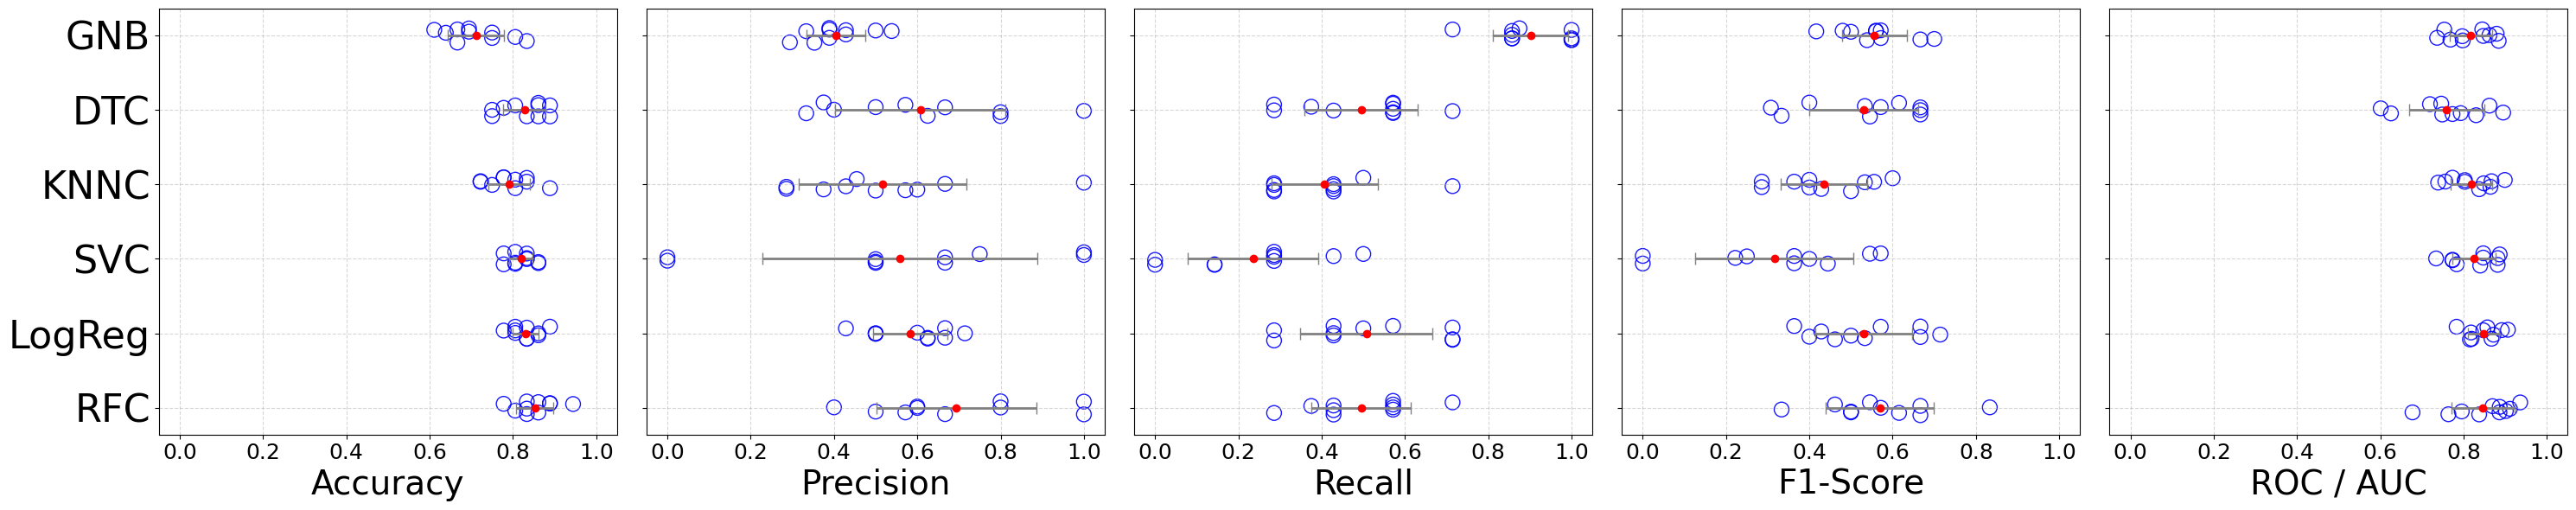

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB


# ── 3) DEFINE MODELS ────────────────────────────────────────────────────────
models = [
    ("RFC", RandomForestClassifier(n_estimators=100, random_state=42)),
    (
        "LogReg",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]),
    ),
    (
        "SVC",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42)),
        ]),
    ),
    (
        "KNNC",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
    ),
    ("DTC", DecisionTreeClassifier(random_state=42)),
    ("GNB", GaussianNB()),
]

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_folds = 10
xlabel_map = {
    "accuracy":  "Accuracy",
    "precision":  "Precision",
    "recall": "Recall",
    "f1":   "F1-Score",
    "roc_auc":  "ROC / AUC"
}
# ── 4) CROSS-VALIDATION ──────────────────────────────────────────────────────
results = {m: [] for m in scoring_metrics}
all_scores = {m: [] for m in scoring_metrics}

for name, model in models:
    for metric in scoring_metrics:
        # Skip roc_auc if model has no probability or decision_function
        if metric == "roc_auc" and not (
            hasattr(model, "predict_proba") or hasattr(model, "decision_function")
        ):
            continue

        scores = cross_val_score(
            model, X_train, y_train, cv=cv_folds, scoring=metric
        )
        results[metric].append({
            "Model": name,
            "Mean Score": scores.mean(),
            "Std Dev":   scores.std()
        })
        all_scores[metric] += [
            {"Model": name, "Score": s, "Metric": metric}
            for s in scores
        ]

# Convert into DataFrames
results_df    = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame(
    [entry for metric_list in all_scores.values() for entry in metric_list]
)

# ── 5) VISUALIZE WITH VERTICAL JITTER ────────────────────────────────────────
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(30, 6), sharey=True)

# Determine a common x-axis limit
global_scores = all_scores_df["Score"]
x_min, x_max = global_scores.min() - 0.05, global_scores.max() + 0.05

for ax, metric in zip(axes, scoring_metrics):
    df_res = results_df[metric]
    
    # Scatter each CV fold with a small jitter around the model's y-index
    for i, row in df_res.iterrows():
        model_name = row["Model"]
        scores     = all_scores_df.query(
            "Model == @model_name and Metric == @metric"
        )["Score"].values
        
        # Add vertical jitter in [-0.1, +0.1]
        y_jitter = i + np.random.uniform(-0.1, 0.1, size=scores.shape)
        
        ax.scatter(
            scores,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.9,
            s=150,
        )

    # Plot mean ± std exactly at y=i
    ax.errorbar(
        df_res["Mean Score"],
        range(len(df_res)),
        xerr=df_res["Std Dev"],
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=5,
    )

    ax.tick_params(axis='x', labelsize=18)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(range(len(df_res)))
    ax.set_yticklabels(df_res["Model"], fontsize=32)
    ax.set_xlabel(xlabel_map[metric], fontsize=28)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Adding SMOTE to increase unbalanced caffeine > 0

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

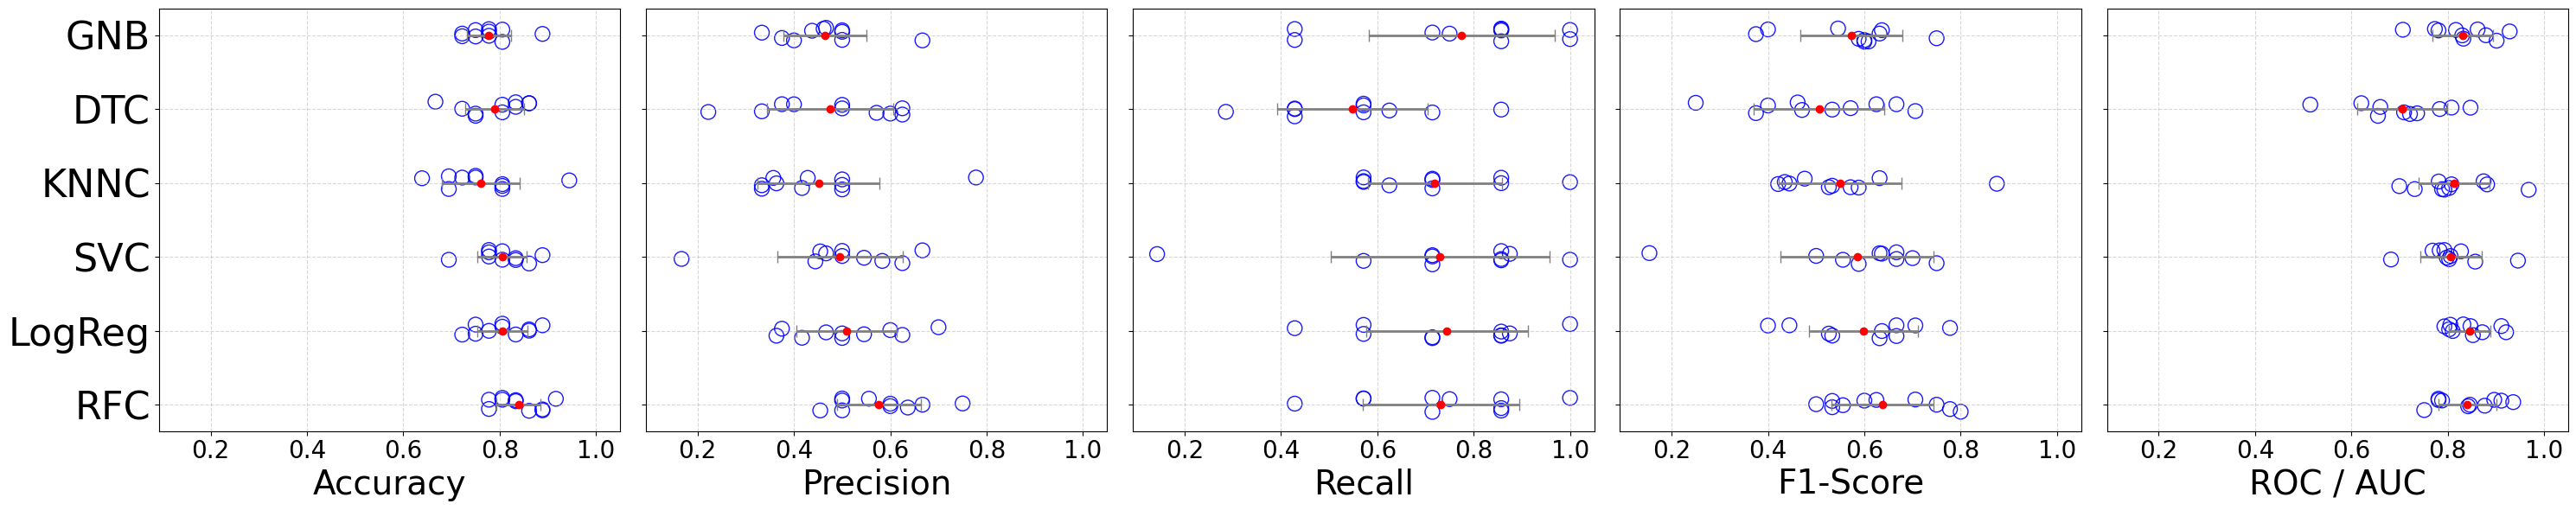

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.pipeline       import Pipeline
from imblearn.over_sampling  import SMOTE


# ── 3) DEFINE MODELS ────────────────────────────────────────────────────────
models = [
    ("RFC", Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf",   RandomForestClassifier(n_estimators=100, random_state=42))
    ])),    
    ("LogReg",
        Pipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]),
    ),
    ("SVC",
        Pipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=42)),
        ]),
    ),
    ("KNNC",
        Pipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier()),
        ]),
    ),
    ("DTC", Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf",   DecisionTreeClassifier(random_state=42))
    ])),

    ("GNB", Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf",   GaussianNB())
    ])),
]

scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_folds = 10
xlabel_map = {
    "accuracy":  "Accuracy",
    "precision":  "Precision",
    "recall": "Recall",
    "f1":   "F1-Score",
    "roc_auc":  "ROC / AUC"
}
# ── 4) CROSS-VALIDATION ──────────────────────────────────────────────────────
results = {m: [] for m in scoring_metrics}
all_scores = {m: [] for m in scoring_metrics}

for name, model in models:
    for metric in scoring_metrics:
        # Skip roc_auc if model has no probability or decision_function
        if metric == "roc_auc" and not (
            hasattr(model, "predict_proba") or hasattr(model, "decision_function")
        ):
            continue

        scores = cross_val_score(
            model, X_train, y_train, cv=cv_folds, scoring=metric
        )
        results[metric].append({
            "Model": name,
            "Mean Score": scores.mean(),
            "Std Dev":   scores.std()
        })
        all_scores[metric] += [
            {"Model": name, "Score": s, "Metric": metric}
            for s in scores
        ]

# Convert into DataFrames
results_df    = {metric: pd.DataFrame(results[metric]) for metric in scoring_metrics}
all_scores_df = pd.DataFrame(
    [entry for metric_list in all_scores.values() for entry in metric_list]
)

# ── 5) VISUALIZE WITH VERTICAL JITTER ────────────────────────────────────────
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(30, 6), sharey=True)

# Determine a common x-axis limit
global_scores = all_scores_df["Score"]
x_min, x_max = global_scores.min() - 0.05, global_scores.max() + 0.05

for ax, metric in zip(axes, scoring_metrics):
    df_res = results_df[metric]
    
    # Scatter each CV fold with a small jitter around the model's y-index
    for i, row in df_res.iterrows():
        model_name = row["Model"]
        scores     = all_scores_df.query(
            "Model == @model_name and Metric == @metric"
        )["Score"].values
        
        # Add vertical jitter in [-0.1, +0.1]
        y_jitter = i + np.random.uniform(-0.1, 0.1, size=scores.shape)
        
        ax.scatter(
            scores,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.9,
            s=150,
        )

    # Plot mean ± std exactly at y=i
    ax.errorbar(
        df_res["Mean Score"],
        range(len(df_res)),
        xerr=df_res["Std Dev"],
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=5,
    )

    ax.tick_params(axis='x', labelsize=20)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(range(len(df_res)))
    ax.set_yticklabels(df_res["Model"], fontsize=32)
    ax.set_xlabel(xlabel_map[metric], fontsize=28)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [9]:
rows = []
for metric, df in results_df.items():
    for _, r in df.iterrows():
        rows.append({
            "Model":       r["Model"],
            f"{metric} Mean": r["Mean Score"],
            f"{metric} Std":  r["Std Dev"]
        })
summary = (pd.DataFrame(rows)
             .groupby("Model")
             .first()  # aggregate since each model appears once per metric
             .round(4))
print("\n=== Combined summary table ===")
print(summary)


=== Combined summary table ===
        accuracy Mean  accuracy Std  precision Mean  precision Std  recall Mean  recall Std  f1 Mean  f1 Std  roc_auc Mean  roc_auc Std
Model                                                                                                                                  
DTC            0.7889        0.0611          0.4752         0.1307       0.5482      0.1557   0.5059  0.1350        0.7057       0.0928
GNB            0.7778        0.0465          0.4641         0.0865       0.7750      0.1930   0.5735  0.1057        0.8312       0.0626
KNNC           0.7611        0.0807          0.4510         0.1264       0.7196      0.1383   0.5502  0.1271        0.8129       0.0736
LogReg         0.8056        0.0527          0.5092         0.1045       0.7446      0.1679   0.5989  0.1132        0.8448       0.0429
RFC            0.8389        0.0461          0.5763         0.0871       0.7321      0.1623   0.6381  0.1060        0.8410       0.0604
SVC            0

In [10]:
import pandas as pd

file_path = r'../input/column_mapping.csv'  

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))

# Replace feature names in the SHAP summary plot data
X_train_renamed = X_train.rename(columns=name_mapping)

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Define final model
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Fit on the full training dataset
final_model.fit(X, y)


RandomForestClassifier(class_weight='balanced', random_state=42)

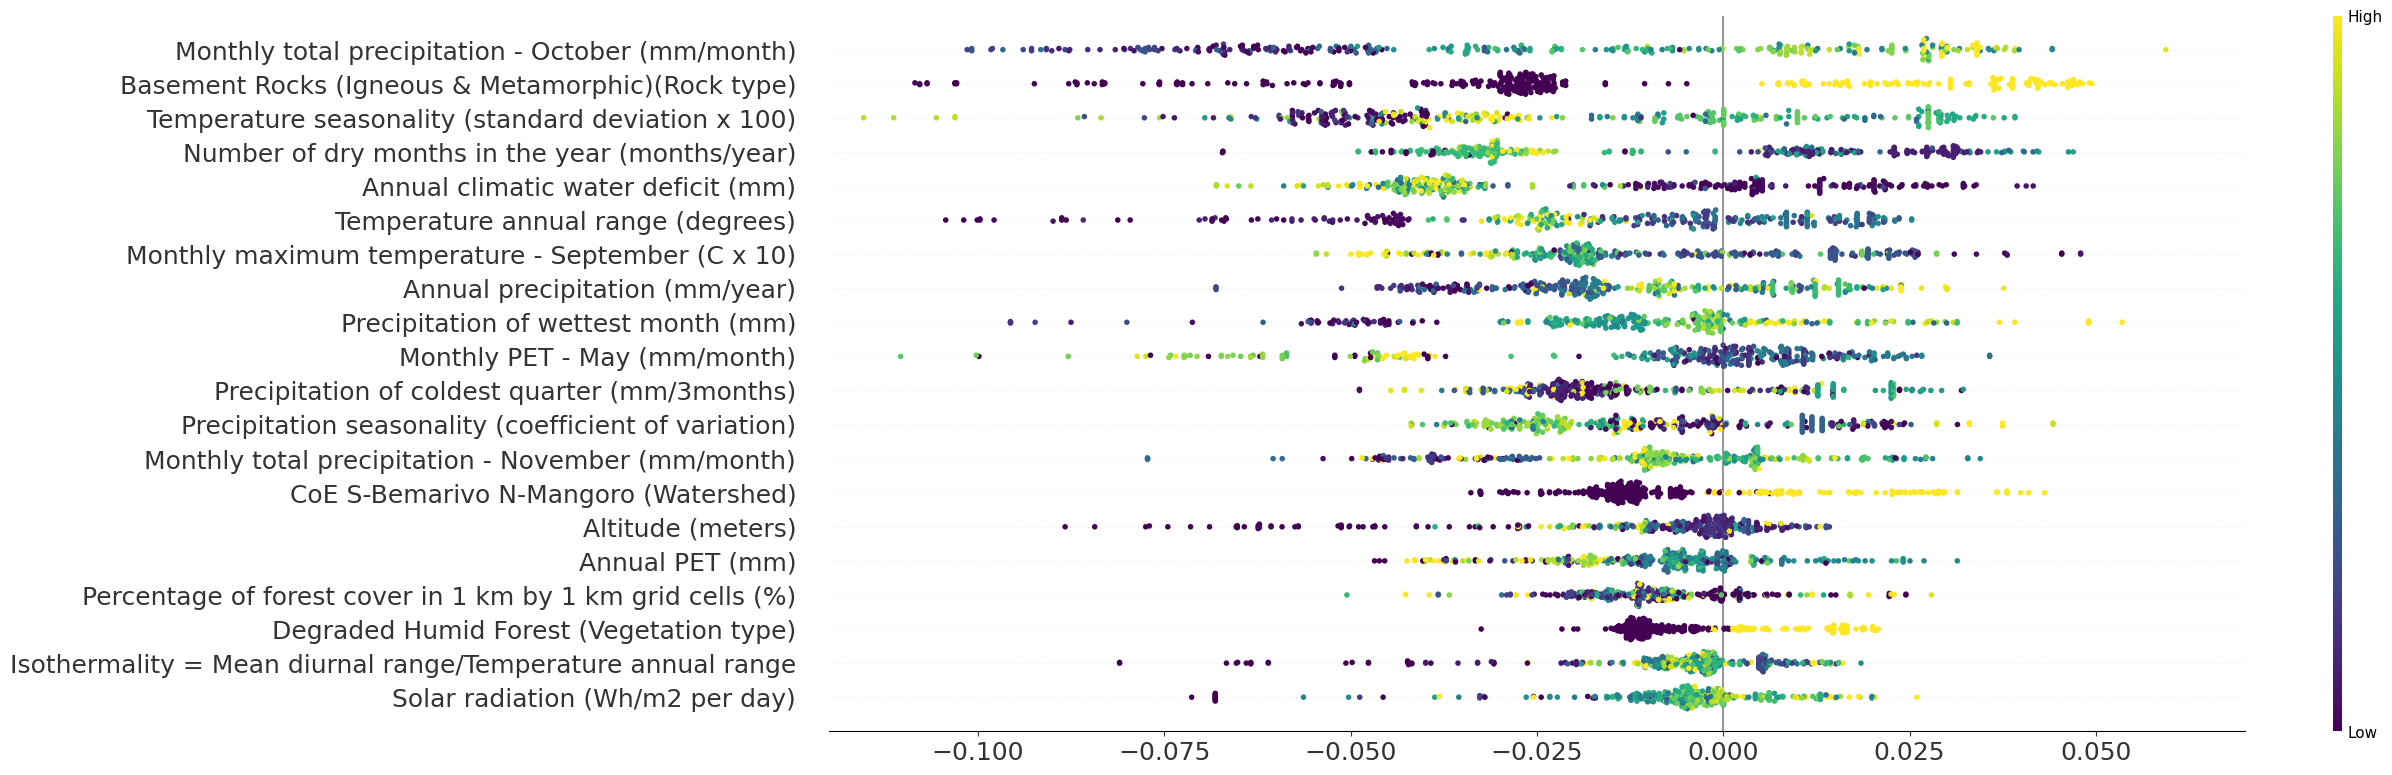

In [21]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# 1) Use the *same* feature matrix you want in the plot (with names).
#    If you already built it, use X_train_renamed directly.
X_shap = X_train_renamed.copy()

# 2) TreeExplainer for RandomForestClassifier
#    model_output="probability" makes SHAP values interpretable on probability scale
explainer = shap.TreeExplainer(
    final_model,
    feature_perturbation="interventional"
)

# 3) Compute SHAP values
shap_values = explainer.shap_values(X_shap)

# 4) Extract class 1 SHAP values robustly
if isinstance(shap_values, list):
    # older API: list length = n_classes
    shap_values_class1 = shap_values[1]
else:
    # array API: could be (n, p) or (n, p, 2)
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3 and shap_values.shape[2] == 2:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

# 5) Plot beeswarm
plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_values_class1, X_train_renamed, plot_size=(24, 8), show=False, cmap='viridis')
plt.xlim(-0.12, 0.07)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()


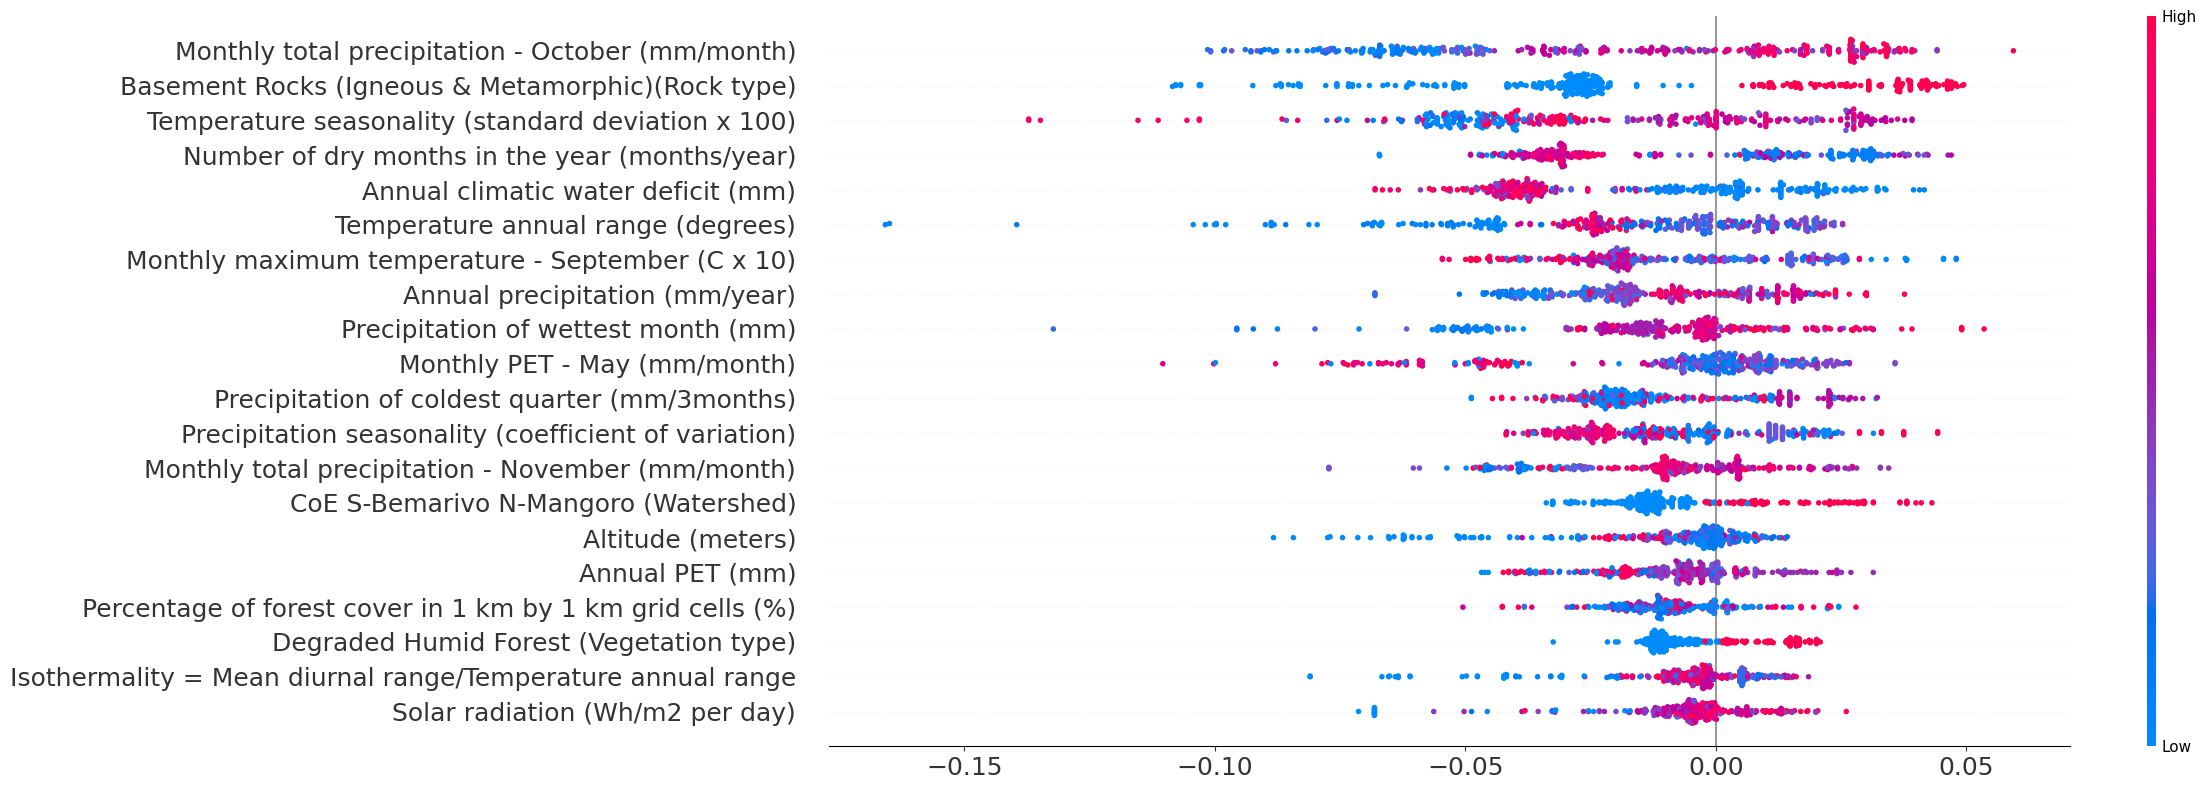

In [16]:
plt.figure(figsize=(14, 8))
shap.summary_plot(
    shap_values_class1,
    X_shap,
    plot_size=(24, 8),
    show=False
)

fig = plt.gcf()
for ax in fig.axes:
    if "colorbar" in ax.get_label().lower():
        ax.set_ylabel("")

plt.xlabel("")
plt.ylabel("")
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
import numpy as np

abs_sv = np.abs(shap_values_class1)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": abs_sv.mean(axis=0),
    "max_abs_shap": abs_sv.max(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

importance_df["rel_to_top"] = importance_df["mean_abs_shap"] / importance_df.loc[0, "mean_abs_shap"]

importance_df.head(15)


,feature,mean_abs_shap,max_abs_shap,rel_to_top
0,Monthly total precipitation - October (mm/month),0.038648,0.101446,1.000000
1,Basement Rocks (Igneous & Metamorphic)(Rock type),0.036649,0.108452,0.948273
2,Temperature seasonality (standard deviation x 100),0.033654,0.137160,0.870766
3,Number of dry months in the year (months/year),0.026378,0.067198,0.682515
4,Annual climatic water deficit (mm),0.026310,0.068028,0.680758
5,Temperature annual range (degrees),0.024907,0.165775,0.644453
6,Monthly maximum temperature - September (C x 10),0.020355,0.054611,0.526669
7,Annual precipitation (mm/year),0.019830,0.068059,0.513093
8,Precipitation of wettest month (mm),0.019540,0.132243,0.505581
9,Monthly PET - May (mm/month),0.018749,0.110382,0.485119


In [26]:
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

def _extract_tree_estimator(fitted_model):
    """
    Return the final tree estimator for SHAP.
    Supports:
      - sklearn tree models directly (RFC, etc.)
      - imblearn Pipeline with a final step named 'clf'
    """
    if isinstance(fitted_model, Pipeline):
        if "clf" not in fitted_model.named_steps:
            raise ValueError(f"Pipeline steps: {list(fitted_model.named_steps)}. Expected a 'clf' step.")
        return fitted_model.named_steps["clf"]
    return fitted_model

def shap_top_features_raw(model, X, y, topk=10, class_index=1):
    """
    Compute mean(|SHAP|) feature importance for the positive class (class_index=1),
    handling SHAP outputs:
      - list [class0, class1]
      - ndarray (n_samples, n_features, 2)
      - ndarray (n_samples, n_features)
    If model is an imblearn Pipeline, fits it, then explains the final estimator.
    """
    # Fit full model (pipeline or estimator)
    model.fit(X, y)

    est = _extract_tree_estimator(model)

    # Explain raw output; for classifier it’s typically margin/log-odds-ish depending on model
    explainer = shap.TreeExplainer(est)
    sv = explainer.shap_values(X)

    # Force class 1 SHAP matrix (n_samples, n_features)
    if isinstance(sv, list):
        sv_class = sv[class_index]
    else:
        sv = np.asarray(sv)
        if sv.ndim == 3 and sv.shape[2] >= 2:
            sv_class = sv[:, :, class_index]
        elif sv.ndim == 2:
            sv_class = sv
        else:
            raise ValueError(f"Unexpected SHAP values shape: {sv.shape}")

    imp = np.abs(sv_class).mean(axis=0)
    return pd.Series(imp, index=X.columns).sort_values(ascending=False).head(topk)

# ---- Candidates ----
candidates = {
    "RFC_balanced_100": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "RFC_balanced_200": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "RFC_unweighted_100": RandomForestClassifier(n_estimators=100, random_state=42),
    "SMOTE_RFC_100": Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
}

for name, model in candidates.items():
    top = shap_top_features_raw(model, X, y, topk=8, class_index=1)
    print(f"\n{name}")
    print(top.index.tolist()[:5])



RFC_balanced_100
['clim_34_prec10_oct', 'env_75_geo_10', 'clim_40_temp_season', 'clim_70_ndm_per_year', 'clim_69_cwd_annual']

RFC_balanced_200
['clim_34_prec10_oct', 'env_75_geo_10', 'clim_40_temp_season', 'clim_43_tannual_range', 'clim_69_cwd_annual']

RFC_unweighted_100
['env_75_geo_10', 'clim_34_prec10_oct', 'clim_70_ndm_per_year', 'clim_40_temp_season', 'clim_55_prec_coldest_q']

SMOTE_RFC_100
['clim_40_temp_season', 'clim_43_tannual_range', 'clim_34_prec10_oct', 'clim_70_ndm_per_year', 'clim_69_cwd_annual']


In [24]:
print(type(shap_values))
print(np.asarray(shap_values).shape if not hasattr(shap_values, "values") else shap_values.values.shape)


<class 'numpy.ndarray'>
(360, 88, 2)


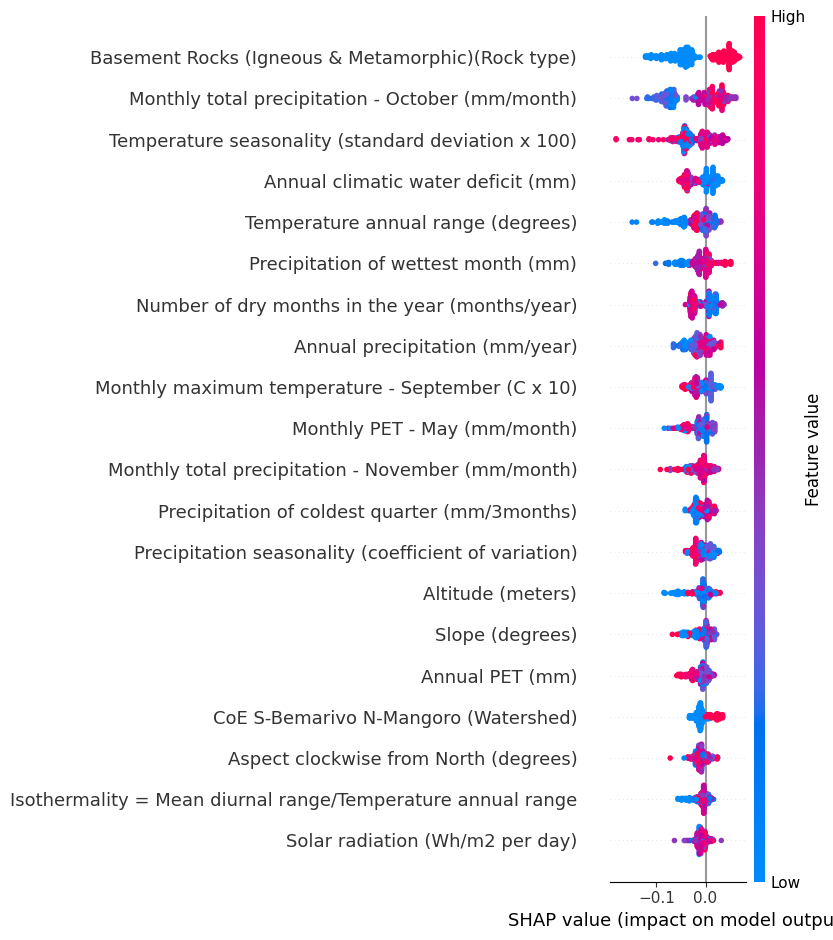

                                                        feature  mean_abs_shap
20            Basement Rocks (Igneous & Metamorphic)(Rock type)       0.047877
7              Monthly total precipitation - October (mm/month)       0.043535
10           Temperature seasonality (standard deviation x 100)       0.032854
12                           Annual climatic water deficit (mm)       0.023847
6                            Temperature annual range (degrees)       0.022686
3                           Precipitation of wettest month (mm)       0.019693
13               Number of dry months in the year (months/year)       0.019418
4                                Annual precipitation (mm/year)       0.019055
1              Monthly maximum temperature - September (C x 10)       0.016520
5                                  Monthly PET - May (mm/month)       0.016260
8             Monthly total precipitation - November (mm/month)       0.015853
2                 Precipitation of coldest quarter (

In [58]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def shap_rank_and_plot_rfc(rfc_model, X_plot, y, class_index=1, topk=20):
    # 1) Fit the model exactly once
    rfc_model.fit(X_plot, y)

    # 2) SHAP on the SAME X used for plotting
    explainer = shap.TreeExplainer(rfc_model)
    sv = explainer.shap_values(X_plot)

    # 3) Extract class-1 SHAP matrix (n_samples, n_features)
    if isinstance(sv, list):
        sv1 = sv[class_index]
    else:
        sv = np.asarray(sv)
        sv1 = sv[:, :, class_index]  # (n, p, 2) -> (n, p)

    # 4) Mean(|SHAP|) ranking
    mean_abs = np.abs(sv1).mean(axis=0)
    rank = (
        pd.DataFrame({"feature": X_plot.columns, "mean_abs_shap": mean_abs})
          .sort_values("mean_abs_shap", ascending=False)
          .head(topk)
    )

    # 5) Beeswarm plot (should match the ranking)
    shap.summary_plot(sv1, X_plot, show=False)
    plt.show()

    return rank

# Example: pick the model you believe produced the figure
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight="balanced"
)

# IMPORTANT: use the exact same X you used for the beeswarm figure
# (X_train_renamed vs X_train vs full X makes a difference)
rank_df = shap_rank_and_plot_rfc(model, X_train_renamed, y_train, class_index=1, topk=20)
print(rank_df)
